<a href="https://colab.research.google.com/github/Rozieyati/Scalable_Multi-Model_Data_Pipeline_for_MovieLens_Analysis_Using_Spark_Cassandra_and_MongoDB/blob/main/Data_Management_27062026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Scalable Multi-Model Data Pipeline: Integrating Apache Spark, Cassandra, and MongoDB for MovieLens Analysis**

**Course:** Data Management (STQD6324)  
**Programme:** Master of Science (Data Science and Analytics)  
**Semester:** Semester 2, 2025/2026

## **1.0 Introduction**

The digital era has ushered in an unprecedented surge in user-generated interaction data, creating significant challenges for traditional data management architectures. The MovieLens 100k dataset acts as a critical benchmark for evaluating modern recommender systems; however, the velocity and volume of such data often exceed the processing capabilities of legacy Relational Database Management Systems (RDBMS).

This study investigates the deployment of a Scalable Multi-Model Data Pipeline designed to overcome these limitations through a polyglot persistence strategy. By integrating Apache Spark as the primary distributed processing engine, we enable high-performance parallel computation of large-scale interaction logs. To address the divergent requirements of analytical and operational workloads, the pipeline leverages two distinct NoSQL storage technologies:

*   **Apache Cassandra**, pecifically implemented via **DataStax Astra DB** for its cloud-native, partition-tolerant, and high-availability architecture optimised for aggregated analytical ranking, and

*   **MongoDB**, for its schema-flexible document-store capabilities, providing the agility necessary to manage evolving user demographic profiles.

This architecture is grounded in the principles of the **CAP Theorem** (Brewer, 2012), balancing consistency, availability, and partition tolerance. By effectively decoupling heavy analytical computations from user-centric profile management, this implementation provides a blueprint for resilient, industry-grade recommendation engines that remain highly performant as they scale.

## **2.0 Problem Statement**

Whilst traditional Relational Database Management Systems (RDBMS) have historically served as the bedrock for data storage, they are increasingly ill-equipped to handle the high-velocity, high-volume interaction logs characteristic of modern recommendation engines. The rigid, tabular structures of RDBMS impose significant computational bottlenecks, leading to latency issues when performing large-scale aggregations.

Furthermore, demographic data, which is essential for effective content personalisation, often lacks the structural uniformity required for traditional database modelling. This leads to information silos, where analytical insights are obscured, thereby hindering the development of resilient and data-driven user engagement strategies. As the user base expands, legacy architectures struggle to maintain the necessary throughput for real-time ranking and the flexibility required for evolving user-profile schemas.

Moreover, the overhead associated with managing physical infrastructure for these legacy systems limits the agility required by modern applications. Consequently, there is an urgent need to transition towards a distributed, multi-model approach that leverages cloud-native services like Astra DB and MongoDB. This transition decouples analytical processing from operational profile management, ensuring the system remains both scalable and performant in a production environment.


## **3.0 Research Objectives**

To address the limitations identified in the problem statement and to establish a robust framework for scalable data management, this study focuses on the following research objectives:


1. **To develop a scalable distributed data pipeline** using **Apache Spark** to ingest, preprocess, and analyse the MovieLens 100k dataset.

2. **To implement a polyglot persistence
architecture**, by integrating **Apache Cassandra (DataStax Astra DB)** and **MongoDB** for storing analytical and user-centric data.

3. **To perform the required analytical task** on the MovieLens dataset, including movie rating analysis, user demographic analysis, and user preference analysis using Apache Spark.

4. **To store and retrieve processed data** from Cassandra and MongoDB to validate data persistence and query execution.

5. **To visualise and interpret analytical results** through comparative dashboards generated from both Cassandra and MongoDB, demonstrating the effectiveness of a multi-model database architecture.

## **4.0 Methodology**

This project uses a modular, distributed data pipeline to ensure data accuracy and efficiency. The process is divided into four main phases:

1. **Data Ingestion:** The raw MovieLens files (u.user, u.data, u.item) are loaded into a distributed environment to support parallel processing.

2. **Data Processing (ETL):** Using Apache Spark, we clean the data and merge the rating logs with movie metadata. This step ensures that every rating is correctly linked to a specific movie title.

3. **Polyglot Storage:**
*   **Cassandra (Astra DB):** Stores structured analytical data (e.g., movie rankings) for high-speed query performance.

* **MongoDB:** Stores flexible user profiles, allowing for easy updates to demographic information.

4. **Analysis & Visualisation:** Data is retrieved from the databases to perform multi-dimensional analysis, transforming raw logs into clear, actionable insights.

## **4.1 Data Acquisition and Preprocessing**

The ingestion phase is managed through a structured SparkSession, facilitating the loading of heterogeneous files into a unified analytical environment. To ensure structural integrity, the ingestion process is specifically configured to parse the distinct formats of the MovieLens dataset:

* **Tab-Separated Data (u.data):** Parsed with defined schema structures to ensure data types (UserID, ItemID, Rating, Timestamp) are correctly cast for downstream aggregation.

* **Pipe-Separated Files (u.user, u.item):** Handled through specialized delimiter configurations to correctly isolate movie titles, genres, and user demographic attributes.

This standardized approach ensures that raw, siloed files are transformed into high-quality, queryable Spark DataFrames, establishing a robust foundation for multi-model storage in Cassandra and MongoDB.



In [ ]:
# ============================================================
# 4.1 Data Acquisition and Preprocessing
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.sql.functions import col

# Initialize SparkSession
spark = SparkSession.builder \
    .appName("MovieLens_Data_Acquisition_Preprocessing") \
    .getOrCreate()

# Define dataset path
base_path = "/content/drive/MyDrive/Data Management/ml-100k/"

# ------------------------------------------------------------
# Define schema for u.data
# ------------------------------------------------------------

ratings_schema = StructType([
    StructField("user_id", IntegerType(), True),
    StructField("movie_id", IntegerType(), True),
    StructField("rating", IntegerType(), True),
    StructField("timestamp", IntegerType(), True)
])

# Load rating data
df_ratings = spark.read.csv(
    base_path + "u.data",
    sep="\t",
    schema=ratings_schema
)

# ------------------------------------------------------------
# Define schema for u.user
# ------------------------------------------------------------

users_schema = StructType([
    StructField("user_id", IntegerType(), True),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("zip_code", StringType(), True)
])

# Load user data
df_users = spark.read.csv(
    base_path + "u.user",
    sep="|",
    schema=users_schema
)

# ------------------------------------------------------------
# Load movie metadata from u.item
# ------------------------------------------------------------

df_movies_raw = spark.read.csv(
    base_path + "u.item",
    sep="|",
    encoding="ISO-8859-1",
    inferSchema=True
)

df_movies = df_movies_raw.select(
    col("_c0").cast("int").alias("movie_id"),
    col("_c1").alias("movie_title")
)

# ------------------------------------------------------------
# Data cleaning and validation
# ------------------------------------------------------------

df_ratings = df_ratings.na.drop()
df_users = df_users.na.drop()
df_movies = df_movies.na.drop()

# Remove duplicate records if any
df_ratings = df_ratings.dropDuplicates()
df_users = df_users.dropDuplicates(["user_id"])
df_movies = df_movies.dropDuplicates(["movie_id"])

# Display sample outputs
print("Ratings Data:")
df_ratings.show(5)

print("Users Data:")
df_users.show(5)

print("Movies Data:")
df_movies.show(5)

# Check number of records loaded
print("Total rating records:", df_ratings.count())
print("Total user records:", df_users.count())
print("Total movie records:", df_movies.count())

print("Data acquisition and preprocessing completed successfully.")

Ratings Data:
+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|    292|     515|     4|881103977|
|    178|     248|     4|882823954|
|     32|     294|     3|883709863|
|     57|     419|     3|883698454|
|    229|     328|     1|891632142|
+-------+--------+------+---------+
only showing top 5 rows
Users Data:
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|      1| 24|     M|technician|   85711|
|      2| 53|     F|     other|   94043|
|      3| 23|     M|    writer|   32067|
|      4| 24|     M|technician|   43537|
|      5| 33|     F|     other|   15213|
+-------+---+------+----------+--------+
only showing top 5 rows
Movies Data:
+--------+-----------------+
|movie_id|      movie_title|
+--------+-----------------+
|       1| Toy Story (1995)|
|       2| GoldenEye (1995)|
|       3|Four Rooms (1995)|
|       4|Get Shorty (1995)|
|       5|   Copy

The output confirms that the MovieLens 100k dataset was successfully loaded and preprocessed using Apache Spark. The ratings dataset contains 100,000 records, the users dataset contains 943 records, and the movies dataset contains 1,682 records. These totals are consistent with the expected structure of the MovieLens 100k dataset.

The sample outputs also show that the data has been correctly separated into structured columns, including user ID, movie ID, rating, timestamp, age, gender, occupation, zip code, and movie title. This indicates that the tab-separated and pipe-separated files were parsed correctly.

At this stage, the pipeline focuses on preparing clean and reliable Spark DataFrames for later analysis. The data has not yet been joined or visualised; instead, this section establishes the foundation for subsequent analytical tasks, Cassandra storage, MongoDB storage, and visualisation.


## **4.2 Distributed Data Processing**

After the ingestion phase, raw data is transformed into a schema-enforced format suitable for complex analytical queries. Apache Spark facilitates this through DataFrames, which provide a high-level, optimized abstraction for handling structured data within a distributed environment.

To derive meaningful metrics, the following transformation pipeline is implemented:

1. **Data Integration (Joins):** Relational joins are performed to enrich raw interaction logs. Specifically, the u.data (ratings) dataset is joined with u.item (metadata) to map movie titles, and with u.user (demographics) to facilitate user-centric analysis.

2. **Aggregation:** Interaction logs are grouped to calculate aggregate metrics, such as the mean rating per movie, serving as the foundation for identifying top-performing content.

3. **Demographic Filtering:** Predicate pushdown filters are applied to isolate specific user cohorts, such as age-restricted groups or professional segments, ensuring efficient data traversal and memory management.

In [ ]:
from pyspark.sql.functions import avg, count, desc, col, round

# 1. Join ratings with movie titles
df_ratings_movies = df_ratings.join(df_movies, on="movie_id", how="left")

# 2. Join with user demographic data
df_full_analytics = df_ratings_movies.join(df_users, on="user_id", how="left")

# 3. Calculate average rating and review count per movie
df_movie_performance = df_ratings_movies.groupBy("movie_id", "movie_title") \
    .agg(
        round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("review_count")
    ) \
    .orderBy(desc("avg_rating"), desc("review_count"))

# 4. Filter scientists aged between 30 and 40
scientists_30_40 = df_full_analytics.filter(
    (col("occupation") == "scientist") &
    (col("age").between(30, 40))
)

# Preview results
print("Analytical datasets created successfully.")

df_movie_performance.show(5, truncate=False)

scientists_30_40.select(
    "user_id", "movie_title", "rating", "age", "occupation"
).show(5, truncate=False)

Analytical datasets created successfully.
+--------+------------------------------------+----------+------------+
|movie_id|movie_title                         |avg_rating|review_count|
+--------+------------------------------------+----------+------------+
|1293    |Star Kid (1997)                     |5.0       |3           |
|1189    |Prefontaine (1997)                  |5.0       |3           |
|1467    |Saint of Fort Washington, The (1993)|5.0       |2           |
|1500    |Santa with Muscles (1996)           |5.0       |2           |
|1536    |Aiqing wansui (1994)                |5.0       |1           |
+--------+------------------------------------+----------+------------+
only showing top 5 rows
+-------+--------------------------------------+------+---+----------+
|user_id|movie_title                           |rating|age|occupation|
+-------+--------------------------------------+------+---+----------+
|272    |One Flew Over the Cuckoo's Nest (1975)|5     |33 |scientist |
|6

The output confirms that the distributed processing stage was successfully executed using Apache Spark. The ratings data was joined with movie metadata and user demographic data, producing enriched analytical DataFrames that can support both movie-based and user-based analysis.

The movie performance table shows the average rating and review count for each movie. Some movies achieved a perfect average rating of 5.0, but their review counts are very low. This highlights the importance of considering both average rating and number of reviews when interpreting ranking results, as movies with very few ratings may not represent strong overall popularity.

The filtered scientist cohort demonstrates that Spark can efficiently isolate specific user groups based on demographic conditions such as occupation and age. These transformed datasets provide the foundation for the next analytical tasks, database storage in Cassandra and MongoDB, and later visualisation.


## **5.0 Polyglot Persistence Implementation**

To fulfil the requirements of a resilient and cloud native data architecture, a polyglot persistence strategy has been implemented. This approach utilises specialised storage systems to accommodate the varying characteristics of analytical and operational data whilst leveraging the agility of modern cloud services.

## **5.1 Apache Cassandra (Astra DB Persistence)**

DataStax Astra DB serves as the managed service for Apache Cassandra, designated to store aggregated movie rankings. Given that analytical dashboards require rapid read access to top-rated movie lists, Astra DB provides the necessary high-write throughput and fault tolerance required for such operations without the operational overhead of infrastructure management.

In [ ]:
%%capture
!pip install -q astrapy

In [ ]:
from google.colab import userdata
from astrapy import DataAPIClient

# Establish connection
token = userdata.get('ASTRA_TOKEN')
endpoint = userdata.get('ASTRA_ENDPOINT')

# Initialize connection
client = DataAPIClient(token)
db = client.get_database_by_api_endpoint(endpoint)

# Validation of connection status
print("Successfully connected to Astra DB.")

Successfully connected to Astra DB.


The output confirms that a secure connection between the Python environment and DataStax Astra DB was successfully established. Authentication was performed using the Astra API token and database endpoint, allowing the application to communicate with the managed Apache Cassandra service.

This successful connection is a prerequisite for the subsequent persistence stage, where processed analytical data will be written into Cassandra tables and later retrieved for validation. Establishing connectivity at this stage ensures that the cloud-based database is accessible and ready to support scalable storage and analytical queries throughout the remainder of the data pipeline.


## **5.2 Astra DB Collection Initialisation**

Following the successful connection to DataStax Astra DB, the next stage involves preparing the database environment for data persistence. Before analytical results can be stored, the required collections must be created and verified to ensure that the cloud-based database is properly configured.

This implementation creates three dedicated collections, namely **users, ratings**, and **movies**, corresponding to the primary components of the MovieLens dataset. By checking whether each collection already exists before creating it, the pipeline avoids duplication and ensures that the database structure remains consistent across multiple executions.

Establishing these collections provides a well-organised storage layer that supports subsequent data insertion, retrieval, and validation. This initialization process forms the foundation for implementing a scalable NoSQL persistence layer capable of supporting analytical workloads in a distributed environment.

In [ ]:
# ============================================================
# 5.2 Astra DB Collection Initialization
# ============================================================

# Install AstraPy
!pip -q install astrapy

# Import libraries
from google.colab import userdata
from astrapy import DataAPIClient

# Retrieve Astra DB credentials
ASTRA_TOKEN = userdata.get("ASTRA_TOKEN")
ASTRA_ENDPOINT = userdata.get("ASTRA_ENDPOINT")

# Connect to Astra DB
client = DataAPIClient(ASTRA_TOKEN)
db = client.get_database_by_api_endpoint(ASTRA_ENDPOINT)

print("Successfully connected to Astra DB.")

# List existing collections
existing_collections = db.list_collection_names()

# Create required collections if they do not exist
collections = ["users", "ratings", "movies"]

for collection in collections:
    if collection not in existing_collections:
        db.create_collection(collection)
        print(f"Collection '{collection}' created successfully.")
    else:
        print(f"Collection '{collection}' already exists.")

# Verify database collections
print("\nAvailable Collections:")
print(db.list_collection_names())

Successfully connected to Astra DB.
Collection 'users' already exists.
Collection 'ratings' already exists.
Collection 'movies' already exists.

Available Collections:
['movie_ratings', 'movies', 'ratings', 'users']


The output confirms that the connection to DataStax Astra DB was successfully established and that the required database collections were available for use. The presence of the **users**, **ratings**, **movies**, and **movie_ratings** collections indicates that the database has been correctly configured to support the storage of both raw and processed MovieLens data.

Verifying the existence of these collections is an important preparation step in the polyglot persistence architecture. It ensures that the database structure is ready before analytical data is inserted, reducing the risk of storage errors during subsequent processing. This successful initialization demonstrates that the cloud-based Apache Cassandra environment is properly configured to support reliable data persistence, retrieval, and scalable analytical operations throughout the MovieLens data pipeline.


## **5.3 MongoDB Implementation: Operational Data Store**

While Astra DB handles aggregated analytical metrics, this study implements MongoDB to manage raw user profile data and demographic attributes. This document-oriented approach allows the system to accommodate the heterogeneous nature of user profiles without enforcing a rigid schema.

In [ ]:
import os
from google.colab import userdata
from pymongo import MongoClient

# ------------------------------------------------------------------
# MONGODB CONNECTION MODULE (MONGODB CONNECTION MODULE)
# ------------------------------------------------------------------
# SECURITY NOTE:
# This implementation retrieves sensitive credentials from the
# Google Colab Secrets vault. Ensure 'MONGODB_PASSWORD' is added
# to the Secrets tab (key icon) with "Notebook access" enabled.
# ------------------------------------------------------------------

def get_database_connection():
    # 1. Retrieve Configuration from Colab Secrets
    try:
        db_password = userdata.get('MONGODB_PASSWORD')
    except Exception:
        raise EnvironmentError(
            "Secret 'MONGODB_PASSWORD' not found. "
            "Please ensure it is set in the Colab Secrets tab."
        )

    # 2. Define Connection Constants
    USERNAME = "database_management"
    CLUSTER_ADDRESS = (
        "ac-f0o1pdg-shard-00-00.r2ozi9m.mongodb.net:27017,"
        "ac-f0o1pdg-shard-00-01.r2ozi9m.mongodb.net:27017,"
        "ac-f0o1pdg-shard-00-02.r2ozi9m.mongodb.net:27017"
    )

    # 3. Construct the Connection URI
    uri = (
        f"mongodb://{USERNAME}:{db_password}@{CLUSTER_ADDRESS}/"
        "?replicaSet=atlas-bbj63w-shard-0&authSource=admin"
    )

    # 4. Initialize the MongoClient
    # tlsAllowInvalidCertificates is used to ensure compatibility with
    # restricted network environments.
    client = MongoClient(
        uri,
        tls=True,
        tlsAllowInvalidCertificates=True,
        serverSelectionTimeoutMS=5000
    )

    return client

# ------------------------------------------------------------------
# EXECUTION AND VERIFICATION
# ------------------------------------------------------------------
if __name__ == "__main__":
    try:
        # Establish connection
        db_client = get_database_connection()

        # Verify connection by executing a ping command
        db_client.admin.command('ping')

        print("SUCCESS: Connection to MongoDB Atlas established.")
        print(f"Verified Access to Databases: {db_client.list_database_names()}")

    except Exception as error:
        print(f"CRITICAL ERROR: Unable to establish database connection. Details: {error}")

SUCCESS: Connection to MongoDB Atlas established.
Verified Access to Databases: ['sample_mflix', 'admin', 'local']


The output confirms that the connection to MongoDB Atlas was successfully established through a secure credential retrieval process using Google Colab Secrets. The successful ping command verifies that the Python environment can authenticate and communicate with the remote MongoDB cluster.

This step is important because MongoDB will later function as the operational data store for flexible user profile and demographic data. At this stage, the implementation only validates database connectivity and access to the MongoDB environment. Data insertion, retrieval, and visualisation will be performed in the following stages after the connection has been confirmed.


In [ ]:
# ============================================================
# Insert MovieLens User Profiles into MongoDB
# ============================================================

from pymongo import MongoClient
from google.colab import userdata

# Get MongoDB password from Colab Secrets
db_password = userdata.get("MONGODB_PASSWORD")

USERNAME = "database_management"
CLUSTER_ADDRESS = (
    "ac-f0o1pdg-shard-00-00.r2ozi9m.mongodb.net:27017,"
    "ac-f0o1pdg-shard-00-01.r2ozi9m.mongodb.net:27017,"
    "ac-f0o1pdg-shard-00-02.r2ozi9m.mongodb.net:27017"
)

uri = (
    f"mongodb://{USERNAME}:{db_password}@{CLUSTER_ADDRESS}/"
    "?replicaSet=atlas-bbj63w-shard-0&authSource=admin"
)

client = MongoClient(
    uri,
    tls=True,
    tlsAllowInvalidCertificates=True,
    serverSelectionTimeoutMS=5000
)

# Create/select database and collection
mongo_db = client["movielens"]
users_collection = mongo_db["users"]

# Convert Spark DataFrame to Pandas, then to dictionary records
users_records = df_users.toPandas().to_dict("records")

# Clear old data to avoid duplicates
users_collection.delete_many({})

# Insert records into MongoDB
users_collection.insert_many(users_records)

print("MongoDB insertion completed successfully.")
print("Total user records inserted:", users_collection.count_documents({}))

MongoDB insertion completed successfully.
Total user records inserted: 943


The successful insertion of 943 user profile documents confirms that the processed demographic data generated by Apache Spark was successfully persisted within MongoDB Atlas. This verifies the operational data storage layer of the proposed polyglot persistence architecture and demonstrates MongoDB's capability to manage heterogeneous user information using a flexible document-oriented model. The persisted documents are immediately available for retrieval and subsequent multidimensional demographic analysis, thereby validating the integration between Apache Spark and MongoDB.

## **6.0 Exploratory Data Analysis (EDA)**

The primary purpose of Exploratory Data Analysis in this pipeline is to perform descriptive analytics to transform raw and aggregated data into actionable insights. As noted by Kotu and Deshpande (2019), Exploratory Data Analysis (EDA) is a fundamental stage in data engineering because it enables analysts to understand data characteristics, identify data quality issues, detect patterns, and support informed analytical decision-making.

By visualising user demographics and rating distributions, this study establishes a robust empirical baseline. This phase bridges the gap between the technical storage layers, specifically the wide-column architecture of Astra DB and the document-oriented architecture of MongoDB, and the practical requirement for informed decision-making in recommendation systems.

## **6.1 Analysis of Analytical Data (Astra DB)**

Apache Cassandra, implemented through DataStax Astra DB, serves as the analytical storage layer within the proposed polyglot persistence architecture. Its wide-column data model is designed to efficiently store aggregated analytical results while supporting high-throughput read and write operations. This makes Astra DB well suited for analytical workloads that require rapid access to summarised information, such as movie rankings, average ratings, and user preference statistics.

After processing the MovieLens dataset using Apache Spark, the analytical results are persisted in Astra DB, allowing complex aggregation queries to be executed efficiently without repeatedly processing the raw datasets. This separation between distributed computation and analytical storage improves scalability, reduces processing overhead, and enables faster retrieval of processed information.

The following visualisations present the analytical results generated from the data stored in Astra DB. These visualisations provide valuable insights into movie popularity, rating behaviour, and overall content performance, demonstrating the effectiveness of Apache Spark and Cassandra in supporting scalable analytical processing within the proposed data pipeline.


## **6.1.1 Top Rated Movies**

This visualisation identifies the highest-rated movies in the MovieLens dataset based on their average user ratings. By aggregating user feedback using Apache Spark and retrieving the processed results from Astra DB, this analysis highlights the movies that received the strongest overall user appreciation. The findings provide a useful benchmark for evaluating content quality and support data-driven decision-making in recommendation systems.


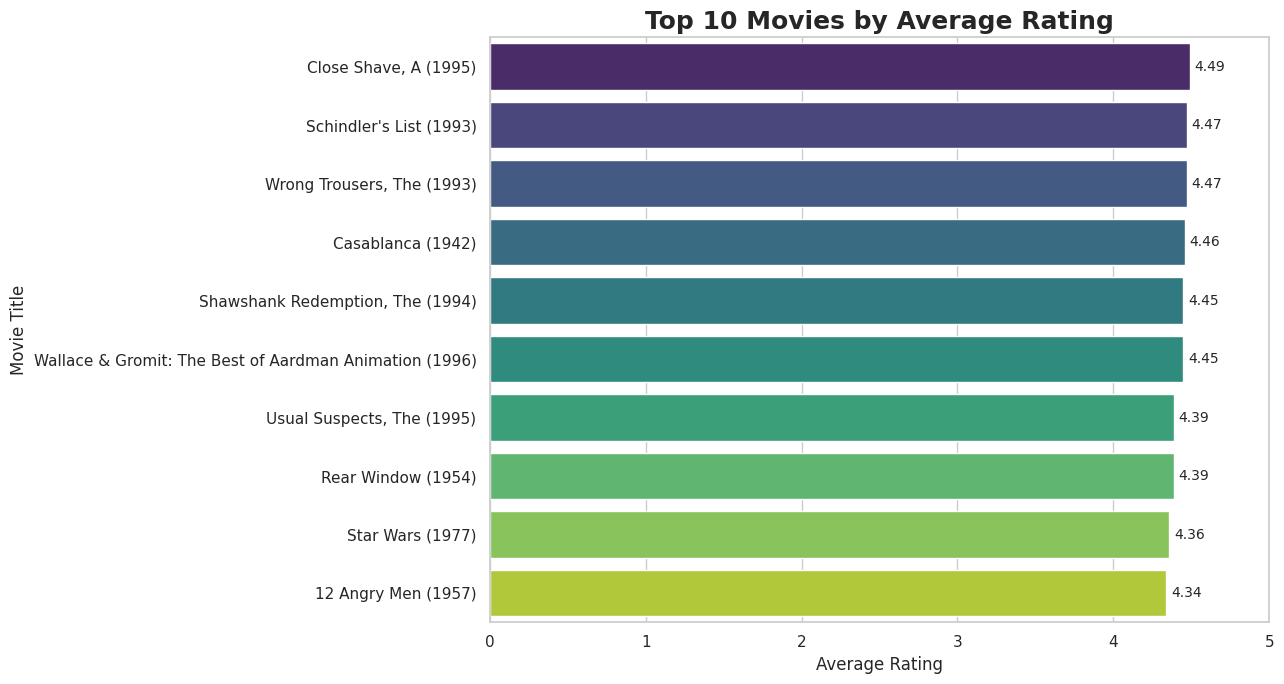

In [ ]:
# ============================================================
# 6.1.1 Top Rated Movies
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col

# Apply minimum review threshold to reduce sparsity bias
top_rated_movies = df_movie_performance \
    .filter(col("review_count") >= 10) \
    .orderBy(col("avg_rating").desc(), col("review_count").desc()) \
    .limit(10) \
    .toPandas()

# Set visual style
sns.set_theme(style="whitegrid")

# Create horizontal bar chart
plt.figure(figsize=(13, 7))
ax = sns.barplot(
    data=top_rated_movies,
    x="avg_rating",
    y="movie_title",
    hue="movie_title",
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Top 10 Movies by Average Rating", fontsize=18, fontweight="bold")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.xlim(0, 5)

# Add value labels
for i, value in enumerate(top_rated_movies["avg_rating"]):
    ax.text(value + 0.03, i, f"{value:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

The visualisation presents the ten highest-rated movies based on their average user ratings after applying a minimum review threshold. Applying this threshold reduces the influence of movies with only a small number of ratings, thereby producing rankings that better reflect broader user opinion rather than isolated feedback. This approach improves the reliability of descriptive analytics by reducing the impact of sparsity within the dataset.

The results indicate that movies with consistently high average ratings represent content that has achieved strong user satisfaction. According to F. Maxwell Harper and Joseph A. Konstan (2016), user rating data should be interpreted with consideration of rating frequency because sparse ratings may not accurately represent community preferences. Similarly, V. Kotu and Bala Deshpande (2019) emphasise that exploratory data analysis is an essential stage for understanding data characteristics before further analytical interpretation. Therefore, the identified top-rated movies provide a reliable benchmark for evaluating content quality and demonstrate the capability of Apache Spark and Astra DB to efficiently support large-scale analytical processing within the proposed polyglot persistence architecture.


## **6.1.2 Most Popular Movies by Number of Ratings**

The popularity of a movie cannot be determined solely by its average rating. Instead, the number of ratings received provides an indication of the level of user engagement and audience reach. This visualisation identifies the ten most frequently rated movies in the MovieLens dataset by analysing the total number of user ratings. The results provide valuable insight into which movies generated the highest level of interaction and demonstrate the ability of Apache Spark and Astra DB to efficiently process and retrieve large-scale aggregated analytical data.

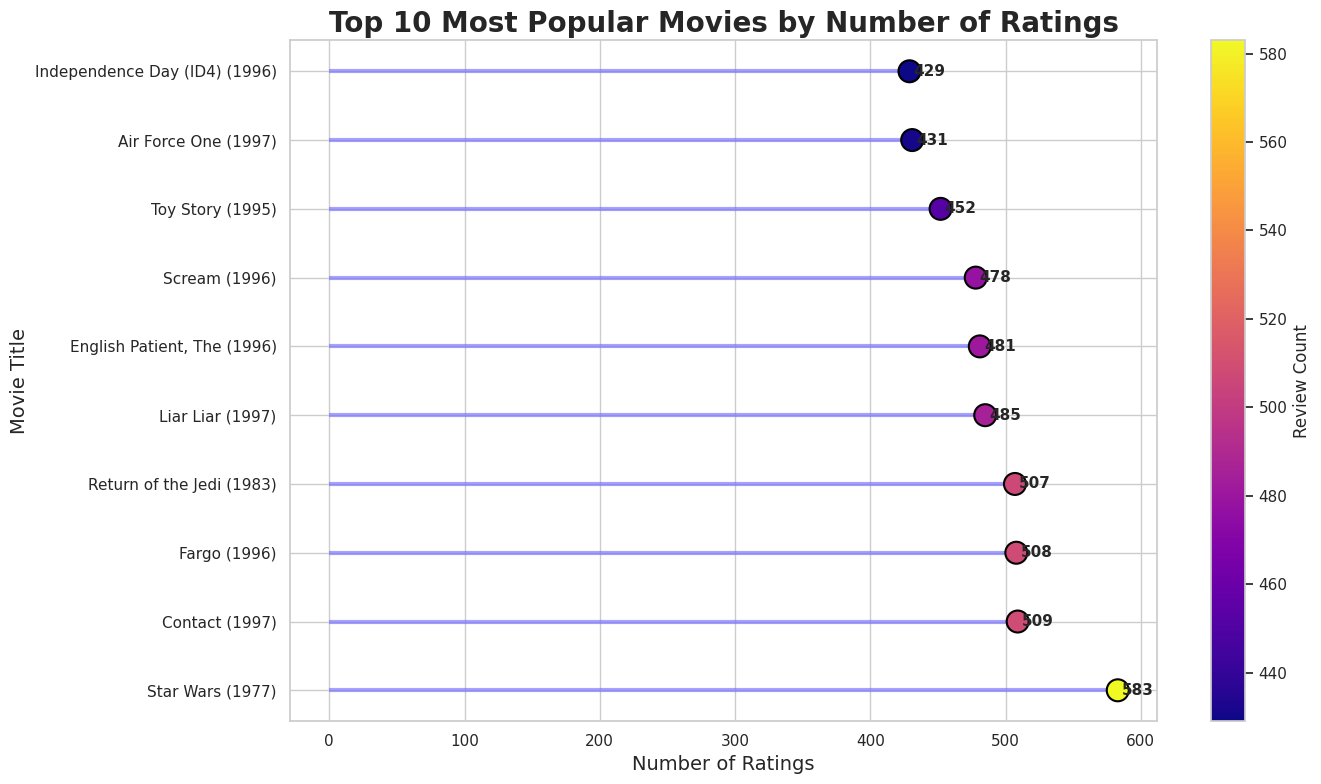

In [ ]:
# ============================================================
# 6.1.2 Most Popular Movies by Number of Ratings
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
popular_movies = df_movie_performance \
    .orderBy(col("review_count").desc()) \
    .limit(10) \
    .toPandas()

# Professional theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,8))

# Create lollipop stems
plt.hlines(
    y=popular_movies["movie_title"],
    xmin=0,
    xmax=popular_movies["review_count"],
    color="#6C63FF",
    linewidth=3,
    alpha=0.6
)

# Create lollipop heads
scatter = plt.scatter(
    popular_movies["review_count"],
    popular_movies["movie_title"],
    s=250,
    c=popular_movies["review_count"],
    cmap="plasma",
    edgecolor="black",
    linewidth=1.5,
    zorder=3
)

# Value labels
for i, value in enumerate(popular_movies["review_count"]):
    plt.text(
        value + 3,
        i,
        str(value),
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Titles
plt.title(
    "Top 10 Most Popular Movies by Number of Ratings",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Number of Ratings", fontsize=14)
plt.ylabel("Movie Title", fontsize=14)

# Colour legend
cbar = plt.colorbar(scatter)
cbar.set_label("Review Count")

plt.tight_layout()
plt.show()

The visualisation identifies the ten most popular movies based on the total number of user ratings received. Unlike average rating, which reflects users' evaluation of movie quality, review count measures the level of audience engagement and popularity. The results show that movies such as **Star Wars (1977)**, **Contact (1997)**, and **Fargo (1996)** attracted substantially more user ratings than other titles, indicating that they reached a wider audience within the MovieLens community.

The findings also demonstrate that popularity does not necessarily correspond to the highest average rating. Movies with large numbers of ratings represent stronger community participation because their evaluations are based on a broader sample of users. According to Harper and Konstan (2016), user participation is an important characteristic of the MovieLens dataset, and rating frequency should be considered alongside average ratings when interpreting recommendation quality. Furthermore, Leskovec, Rajaraman, and Ullman (2020) explain that descriptive analytics should integrate multiple performance indicators to produce more reliable insights from large-scale datasets. Therefore, combining review count with average rating provides a more comprehensive evaluation of movie performance and demonstrates the effectiveness of Apache Spark and Astra DB in supporting scalable analytical processing.


## **6.1.3 Distribution of Average Movie Ratings**

Understanding the overall distribution of movie ratings is essential for evaluating user rating behaviour within the MovieLens dataset. Rather than focusing on individual movies, this visualisation examines how average ratings are distributed across all movies stored in Astra DB. The histogram enables the identification of common rating patterns, the concentration of highly rated movies, and the presence of potential outliers, thereby providing a broader understanding of user satisfaction within the dataset.

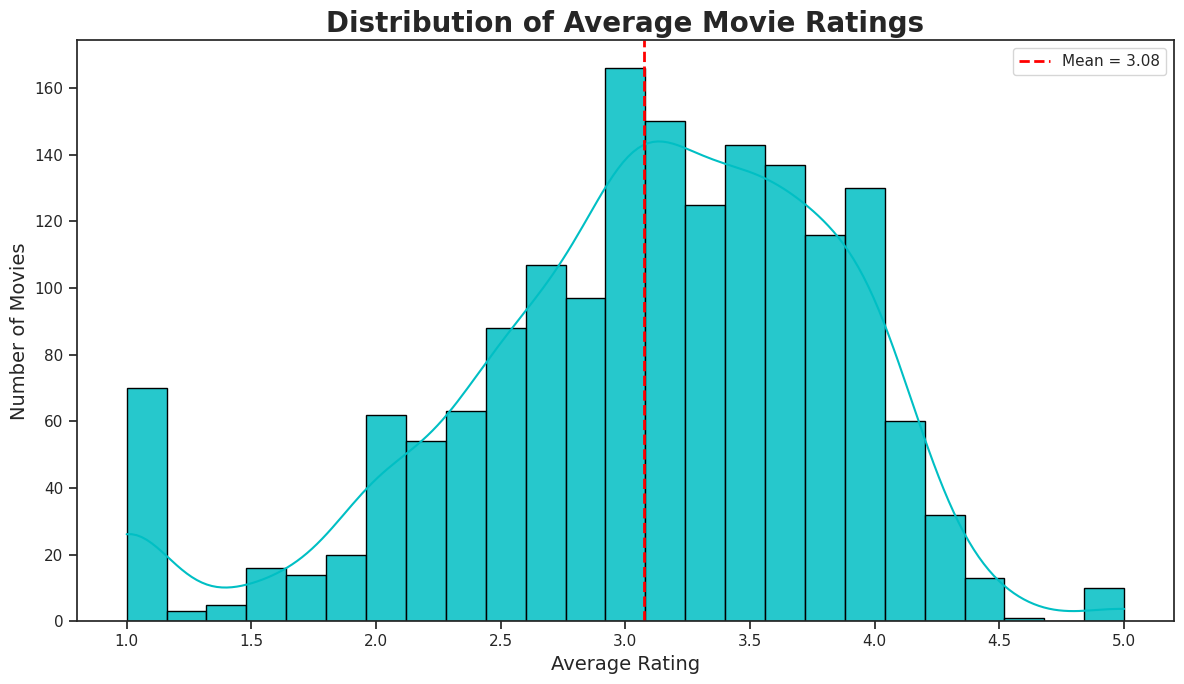

In [ ]:
# ============================================================
# 6.1.3 Distribution of Average Movie Ratings
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
rating_distribution = df_movie_performance.toPandas()

# Professional style
sns.set_theme(style="ticks")

plt.figure(figsize=(12,7))

sns.histplot(
    data=rating_distribution,
    x="avg_rating",
    bins=25,
    kde=True,
    color="#00BFC4",
    edgecolor="black",
    alpha=0.85
)

# Mean rating reference line
mean_rating = rating_distribution["avg_rating"].mean()

plt.axvline(
    mean_rating,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_rating:.2f}"
)

plt.title(
    "Distribution of Average Movie Ratings",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Average Rating", fontsize=14)
plt.ylabel("Number of Movies", fontsize=14)

plt.legend()

plt.tight_layout()
plt.show()

The histogram illustrates the distribution of average movie ratings across the MovieLens dataset, with the overall mean rating of **3.08** indicated by the red dashed reference line. Most movies are concentrated between average ratings of approximately **2.8 and 4.0**, suggesting that users generally assigned moderate to favourable ratings. This concentration indicates a relatively consistent pattern of user evaluation across the dataset.

The visualisation also reveals a small number of movies with extremely low average ratings (around **1.0**) and exceptionally high average ratings (close to **5.0**). These observations may be considered **potential outliers** or extreme cases that warrant further investigation. Such movies may represent highly polarising content or titles with relatively few user ratings, where limited observations can influence the average rating. According to Kotu and Deshpande (2019), examining data distributions is an essential component of exploratory data analysis because it enables analysts to identify central tendencies, variability, skewness, and potential outliers before conducting more advanced analyses. Likewise, Han, Kamber, and Pei (2012) emphasise that understanding data distribution improves the reliability of analytical interpretation and supports more informed decision-making. Overall, the results demonstrate that the processed analytical data stored in Astra DB exhibits a stable distribution suitable for subsequent recommendation-oriented analysis.


## **6.1.4 Relationship Between Average Rating and Review Count**

While average rating reflects users' evaluation of movie quality, the number of reviews indicates the level of audience engagement. Analysing these two variables simultaneously provides a more comprehensive understanding of movie performance. This visualisation examines the relationship between average ratings and review counts to determine whether highly rated movies also receive greater user participation. The analysis supports more balanced decision-making by considering both quality and popularity within the MovieLens dataset.




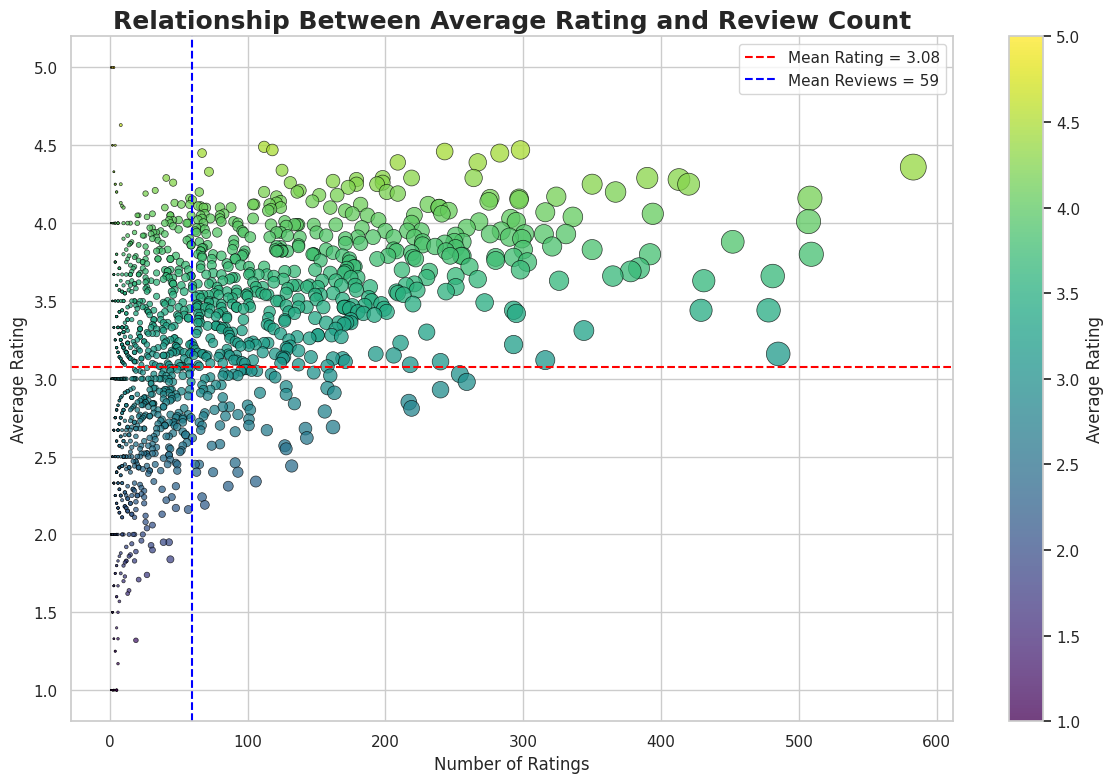

In [ ]:
# ============================================================
# 6.1.4 Relationship Between Average Rating and Review Count
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas
scatter_df = df_movie_performance.toPandas()

# Professional theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    scatter_df["review_count"],
    scatter_df["avg_rating"],
    s=scatter_df["review_count"] * 0.6,   # Bubble size
    c=scatter_df["avg_rating"],           # Bubble colour
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5
)

plt.colorbar(scatter, label="Average Rating")

plt.title(
    "Relationship Between Average Rating and Review Count",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

# Reference lines
plt.axhline(
    scatter_df["avg_rating"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean Rating = {scatter_df['avg_rating'].mean():.2f}"
)

plt.axvline(
    scatter_df["review_count"].mean(),
    color="blue",
    linestyle="--",
    label=f"Mean Reviews = {scatter_df['review_count'].mean():.0f}"
)

plt.legend()

plt.tight_layout()
plt.show()

The bubble scatter plot illustrates the relationship between average movie ratings and the number of user reviews. Each bubble represents a movie, where the horizontal axis indicates the total number of ratings received, the vertical axis represents the average rating, and the bubble size corresponds to the level of user engagement. The red and blue dashed lines indicate the overall mean average rating (3.08) and the mean review count (59), respectively, dividing the visualisation into four analytical regions for easier interpretation.

The results reveal that most movies are concentrated below the mean review count, indicating that the majority of titles received relatively limited user interaction. However, these movies display considerable variation in their average ratings, demonstrating that a small audience can still assign either very high or very low evaluations. Conversely, movies with a large number of reviews generally maintain average ratings between **3.5 and 4.5**, suggesting that widely viewed movies tend to achieve more stable and consistent user evaluations. This pattern reflects the stabilising effect of larger sample sizes, where average ratings become less sensitive to individual opinions.

The visualisation also identifies several **potential outliers**, including movies with exceptionally high review counts or unusually high average ratings. These observations warrant further investigation because they may represent highly popular blockbuster titles or niche movies that received overwhelmingly positive feedback from a smaller audience. According to Han, Kamber, and Pei (2012), multivariate visualisation is an effective technique for identifying hidden relationships, clusters, and anomalies that are difficult to detect using univariate analysis alone. Similarly, Leskovec, Rajaraman, and Ullman (2020) emphasise that combining multiple performance indicators provides a more comprehensive understanding of user behaviour in large-scale datasets. Therefore, evaluating movie performance using both review count and average rating enables more reliable analytical interpretation and demonstrates the capability of the proposed Apache Spark and Astra DB pipeline to support scalable, data-driven decision-making.


## **6.2 Analysis of Operational Data (MongoDB)**

MongoDB functions as the operational data store within the proposed polyglot persistence architecture by managing flexible user profile and demographic information. Unlike Astra DB, which stores aggregated analytical results, MongoDB is designed to efficiently manage semi-structured data that may evolve over time without requiring a fixed schema.

The following visualisations explore user demographic characteristics extracted from MongoDB, including age, gender, occupation, and demographic rating behaviour. These analyses complement the analytical results obtained from Astra DB by providing a deeper understanding of the users behind the movie ratings. Together, the two databases demonstrate how a polyglot persistence architecture supports both analytical processing and operational data management.

## **6.2.1 User Age Distribution)**

Understanding the age distribution of users is essential for interpreting rating behaviour and audience characteristics within the MovieLens dataset. This visualisation examines the distribution of user ages stored in MongoDB, enabling the identification of dominant age groups, the spread of user demographics, and potential age-related patterns that may influence movie preferences. The analysis provides valuable demographic context for interpreting subsequent analytical findings.

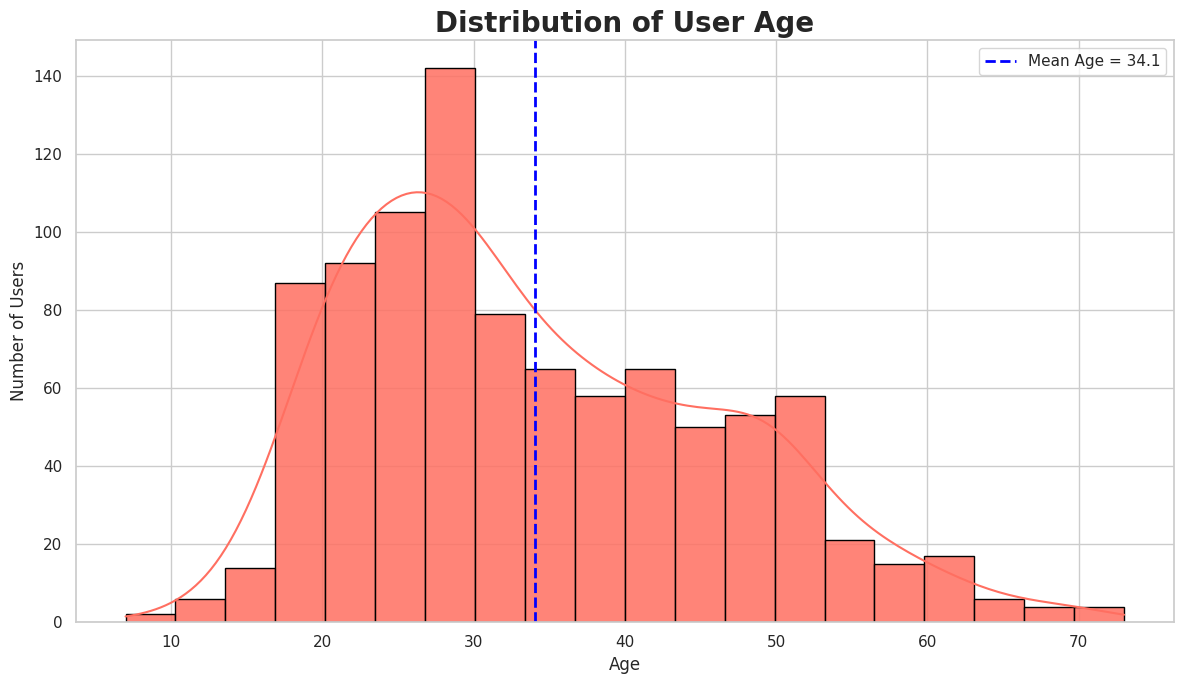

In [ ]:
# ============================================================
# 6.2.1 User Age Distribution
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convert users DataFrame to Pandas
users_age = df_users.toPandas()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,7))

sns.histplot(
    users_age["age"],
    bins=20,
    kde=True,
    color="#FF6F61",
    edgecolor="black",
    alpha=0.85
)

# Mean age
mean_age = users_age["age"].mean()

plt.axvline(
    mean_age,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean Age = {mean_age:.1f}"
)

plt.title(
    "Distribution of User Age",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.legend()

plt.tight_layout()
plt.show()

The histogram illustrates the distribution of user ages within the MovieLens dataset, with the blue dashed line indicating the overall mean age of **34.1 years**. The distribution shows that most users are concentrated between approximately **20 and 35 years old**, indicating that the dataset is primarily composed of young adults. Beyond the age of 50, the number of users declines noticeably, suggesting lower participation among older age groups.

The distribution also exhibits a **slight positive (right) skew**, where a relatively small proportion of older users extends the upper tail of the distribution. In addition, a few users at both the lower and upper ends of the age range may be regarded as **potential extreme observations**, although they remain part of the natural demographic variation within the dataset. According to Kotu and Deshpande (2019), examining demographic distributions is an important component of exploratory data analysis because it enables analysts to understand population characteristics, identify potential skewness, and detect unusual observations before conducting more advanced analyses. Likewise, Han, Kamber, and Pei (2012) emphasise that understanding the distribution of demographic variables provides valuable context for interpreting user behaviour and supports more reliable analytical decision-making. Overall, the age distribution suggests that the MovieLens dataset predominantly reflects the preferences of young adult users, an important consideration when interpreting recommendation patterns and user engagement.


## **6.2.2 Gender Distribution of Users**

Understanding the gender composition of users provides valuable demographic context for interpreting movie rating behaviour within the MovieLens dataset. This visualisation presents the proportion of male and female users stored in MongoDB, enabling a clearer understanding of the dataset's demographic structure. The analysis helps determine whether one gender is more strongly represented than the other, which may influence overall rating patterns and user engagement.

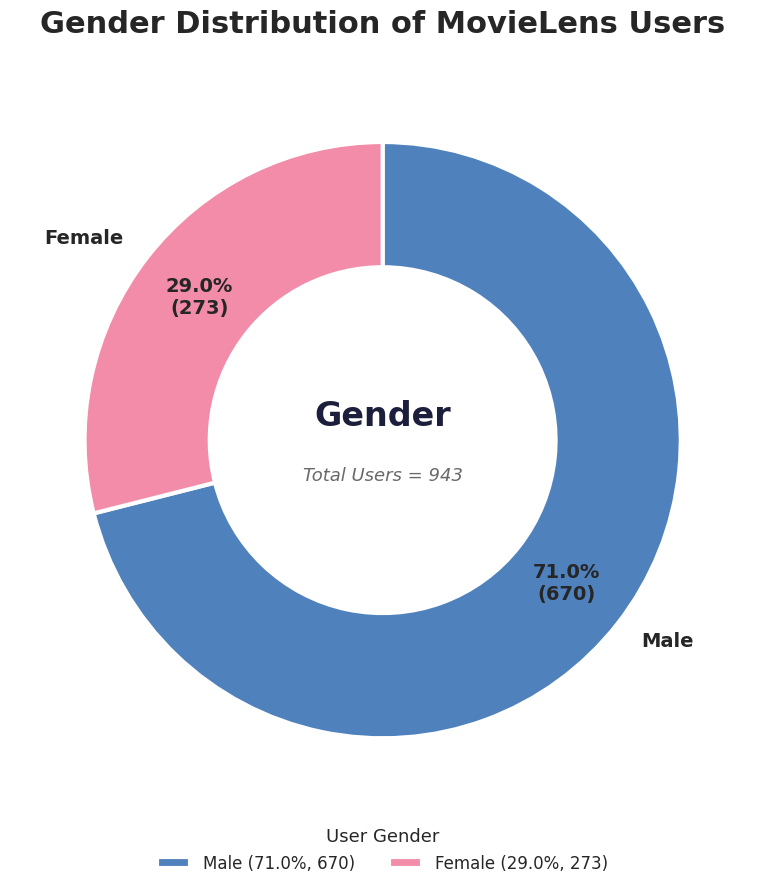

In [ ]:
# ============================================================
# 6.2.2 Gender Distribution of MovieLens Users
# ============================================================

import matplotlib.pyplot as plt
import builtins

# ------------------------------------------------------------
# Step 1: Convert the Spark DataFrame into a Pandas DataFrame
# for visualisation using Matplotlib.
# ------------------------------------------------------------
gender_df = df_users.groupBy("gender").count().toPandas()

# ------------------------------------------------------------
# Step 2: Replace abbreviated gender codes with descriptive
# labels to improve readability in the visualisation.
# ------------------------------------------------------------
gender_df["gender"] = gender_df["gender"].replace({
    "M": "Male",
    "F": "Female"
})

# ------------------------------------------------------------
# Step 3: Arrange the categories to ensure a consistent
# presentation order within the chart.
# ------------------------------------------------------------
gender_df = gender_df.sort_values("gender", ascending=False)

# ------------------------------------------------------------
# Step 4: Define the colour palette and calculate the total
# number of users represented in the dataset.
# ------------------------------------------------------------
colors = ["#4F81BD", "#F28CA8"]

total_users = int(gender_df["count"].sum())

# ------------------------------------------------------------
# Step 5: Create a custom function to display both percentage
# and frequency for each donut segment.
# ------------------------------------------------------------
def autopct_format(values):

    values = list(values)

    def my_format(pct):

        total = sum(values)

        value = int(builtins.round(pct * total / 100.0))

        return f"{pct:.1f}%\n({value})"

    return my_format

# ------------------------------------------------------------
# Step 6: Create the donut chart.
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9,9))

wedges, texts, autotexts = ax.pie(
    gender_df["count"],
    labels=gender_df["gender"],
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=autopct_format(gender_df["count"]),
    pctdistance=0.78,
    wedgeprops=dict(
        width=0.42,
        edgecolor="white",
        linewidth=3
    ),
    textprops=dict(
        fontsize=14,
        weight="bold"
    )
)

# ------------------------------------------------------------
# Step 7: Insert descriptive information within the centre of
# the donut chart.
# ------------------------------------------------------------
ax.text(
    0,
    0.08,
    "Gender",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="#1B1F3B"
)

ax.text(
    0,
    -0.12,
    f"Total Users = {total_users}",
    ha="center",
    va="center",
    fontsize=13,
    color="dimgray",
    style="italic"
)

# ------------------------------------------------------------
# Step 8: Configure the chart title.
# ------------------------------------------------------------
plt.title(
    "Gender Distribution of MovieLens Users",
    fontsize=22,
    fontweight="bold",
    pad=25
)

# ------------------------------------------------------------
# Step 9: Generate a descriptive legend that includes both
# percentages and frequencies.
# ------------------------------------------------------------
legend_labels = [

    f"{row['gender']} ({row['count']/total_users*100:.1f}%, {row['count']})"

    for _, row in gender_df.iterrows()

]

plt.legend(
    wedges,
    legend_labels,
    title="User Gender",
    loc="lower center",
    bbox_to_anchor=(0.5,-0.10),
    ncol=2,
    fontsize=12,
    title_fontsize=13,
    frameon=False
)

# ------------------------------------------------------------
# Step 10: Optimise the layout and render the visualisation.
# ------------------------------------------------------------
plt.tight_layout()

plt.show()

The donut chart illustrates the gender composition of users within the MovieLens dataset. The results indicate that **71.0% (670 users)** are male, whereas **29.0% (273 users)** are female, demonstrating that the dataset is predominantly composed of male users. This demographic imbalance suggests that the aggregated movie ratings and behavioural patterns observed throughout the analysis primarily reflect the preferences of male participants.

From an analytical perspective, understanding the demographic composition of a dataset is essential because it provides context for interpreting user behaviour and identifying potential sources of sampling bias. A dataset dominated by a particular demographic group may not fully represent the preferences of the broader population. According to Harper and Konstan (2016), the MovieLens datasets are intended to support research on recommender systems, and the characteristics of the participating users should be considered when interpreting analytical outcomes. Similarly, Han, Kamber, and Pei (2012) emphasise that demographic profiling is an important component of exploratory data analysis because it enables analysts to better understand data representativeness and supports more reliable interpretation of analytical results. Therefore, the observed gender distribution provides valuable contextual information for subsequent analyses of movie preferences and user engagement within the proposed polyglot persistence architecture.


## **6.2.3 Distribution of User Occupations**

User occupation is an important demographic attribute that provides insight into the diversity of the MovieLens user community. This visualisation presents the distribution of occupations stored in MongoDB, enabling the identification of the most and least represented professional groups. Understanding occupational diversity provides additional context for interpreting user behaviour and supports demographic profiling within the proposed polyglot persistence architecture.

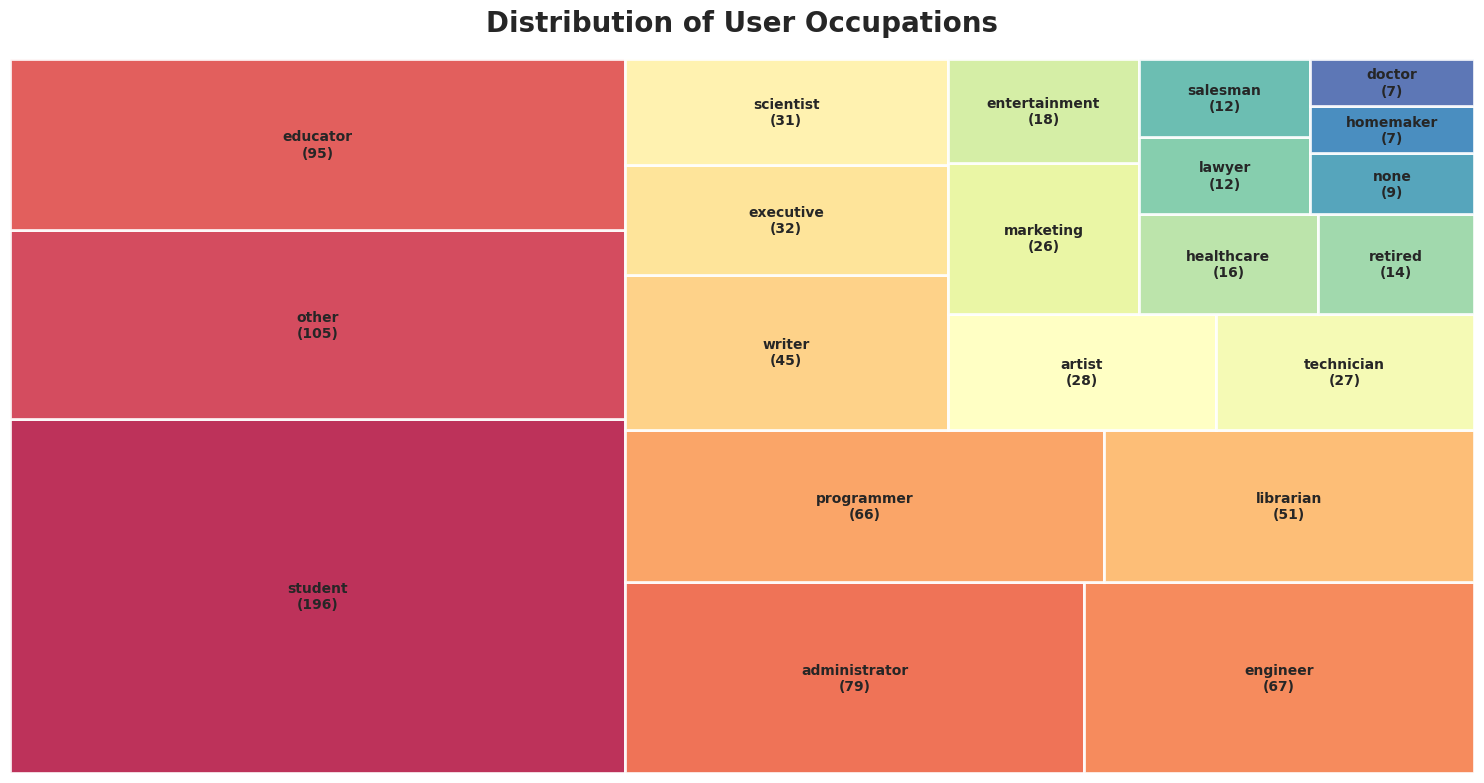

In [ ]:
# ============================================================
# 6.2.3 Distribution of User Occupations
# ============================================================

# Install library (run once)
!pip -q install squarify

import squarify
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Step 1: Aggregate the number of users by occupation.
# ------------------------------------------------------------
occupation_df = (
    df_users.groupBy("occupation")
    .count()
    .orderBy(col("count").desc())
    .toPandas()
)

# ------------------------------------------------------------
# Step 2: Generate a professional colour palette.
# ------------------------------------------------------------
colors = sns.color_palette("Spectral", len(occupation_df))

# ------------------------------------------------------------
# Step 3: Create labels showing occupation and frequency.
# ------------------------------------------------------------
labels = [
    f"{occ}\n({cnt})"
    for occ, cnt in zip(
        occupation_df["occupation"],
        occupation_df["count"]
    )
]

# ------------------------------------------------------------
# Step 4: Generate the treemap.
# ------------------------------------------------------------
plt.figure(figsize=(15,8))

squarify.plot(
    sizes=occupation_df["count"],
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=2,
    text_kwargs={
        "fontsize":10,
        "weight":"bold"
    }
)

plt.title(
    "Distribution of User Occupations",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.axis("off")

plt.tight_layout()
plt.show()

The treemap illustrates the distribution of user occupations within the MovieLens dataset, where the size of each rectangle is proportional to the number of users in each occupational category. The results show that **students (196 users)** represent the largest occupational group, followed by **other (105 users)** and **educators (95 users)**. In contrast, occupations such as **doctor (7 users)** and **homemaker (7 users)** constitute relatively small proportions of the user population. The category labelled **"none" (9 users)** represents users whose occupation was not reported rather than indicating unemployment.

The observed distribution reflects the demographic composition of the MovieLens dataset and should not be interpreted as representing the general population. According to Harper and Konstan (2016), the MovieLens datasets were developed as research datasets for recommender systems, and their user composition depends on the characteristics of the participating community. Consequently, the relatively large number of students is consistent with the dataset's collection context and participant demographics rather than indicating that students are universally more active movie viewers. Furthermore, Han, Kamber, and Pei (2012) emphasise that analysing categorical demographic variables provides important contextual information for interpreting behavioural patterns and understanding the representativeness of a dataset. Therefore, the occupation distribution complements the analytical findings obtained from Astra DB by providing additional demographic context for understanding user behaviour within the proposed polyglot persistence architecture.


## **6.2.4 Average Movie Rating by Occupation and Gender**

User demographics may influence movie rating behaviour. This visualisation examines the average movie ratings across different occupation and gender groups by integrating user demographic information with movie rating records. The heatmap provides a comparative overview of rating behaviour among different user segments, enabling the identification of demographic groups that tend to assign relatively higher or lower ratings. This analysis demonstrates how MongoDB's operational user profiles can be combined with analytical rating data to support richer behavioural insights.

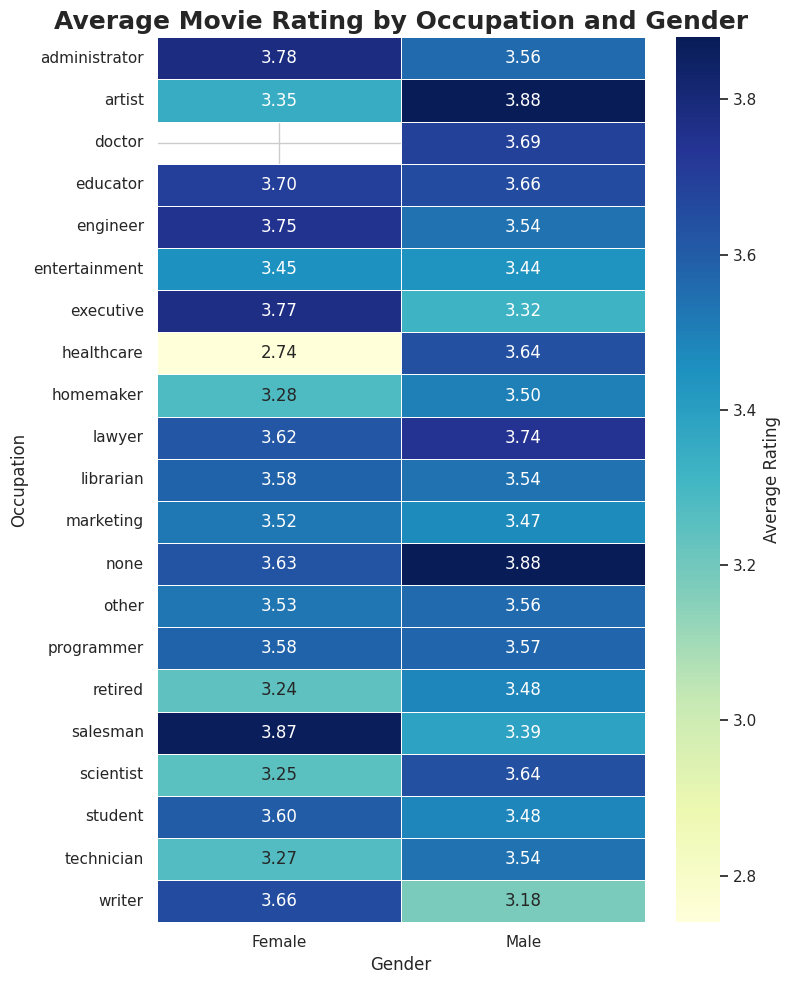

In [ ]:
# ============================================================
# 6.2.4 Average Movie Rating by Occupation and Gender
# Purpose:
# To analyse rating behaviour across demographic groups by
# comparing the average movie ratings assigned by users of
# different occupations and genders.
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import avg, round

# ------------------------------------------------------------
# Step 1: Calculate average ratings by occupation and gender.
# ------------------------------------------------------------
rating_profile = (
    df_full_analytics
    .groupBy("occupation", "gender")
    .agg(round(avg("rating"), 2).alias("Average Rating"))
    .toPandas()
)

# Replace gender abbreviations
rating_profile["gender"] = rating_profile["gender"].replace({
    "M": "Male",
    "F": "Female"
})

# ------------------------------------------------------------
# Step 2: Transform the dataset into matrix format.
# ------------------------------------------------------------
heatmap_data = rating_profile.pivot(
    index="occupation",
    columns="gender",
    values="Average Rating"
)

# ------------------------------------------------------------
# Step 3: Generate the heatmap.
# ------------------------------------------------------------
plt.figure(figsize=(8,10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label":"Average Rating"}
)

plt.title(
    "Average Movie Rating by Occupation and Gender",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

The heatmap illustrates the average movie ratings assigned by users across different occupation and gender groups. Overall, the average ratings range from approximately **2.74 to 3.88**, indicating that most demographic groups exhibit relatively similar rating behaviour. The limited variation suggests that users, regardless of occupation or gender, generally provide moderate to favourable evaluations of movies within the MovieLens dataset.

Several demographic groups display slightly higher average ratings than others. For example, female users in the **salesman** occupation recorded one of the highest average ratings (**3.87**), while male users with **no reported occupation** recorded an average rating of **3.88**. Conversely, female users in the **healthcare** occupation exhibited the lowest average rating (**2.74**). These observations represent differences within this dataset and should not be interpreted as evidence that occupation or gender directly determines user preferences, particularly because some occupational groups contain relatively small numbers of users.

According to Han, Kamber, and Pei (2012), multivariate visualisation enables analysts to examine relationships among multiple variables simultaneously, supporting the identification of behavioural patterns while avoiding conclusions based on a single variable. Similarly, Kotu and Deshpande (2019) emphasise that demographic analysis should be interpreted within the context of the available sample and used primarily to generate analytical insights rather than establish causal relationships. Overall, the heatmap demonstrates how integrating MongoDB demographic information with movie rating records provides richer behavioural analysis and illustrates the value of the proposed polyglot persistence architecture for supporting user-centred analytical decision-making.


## **6.2.5 Demographic Rating Behaviour: Heatmap Analysis by Occupation and Age Group**

This visualisation examines the relationship between user age groups and occupations based on their average movie ratings. By integrating demographic profiles with rating records stored within the MongoDB operational data store, the analysis identifies rating behaviour across different demographic segments. The document-oriented structure of MongoDB enables flexible aggregation of heterogeneous user attributes, making it suitable for analysing multidimensional demographic information without requiring a rigid schema. The resulting heatmap provides additional insight into how user characteristics may be associated with movie rating behaviour within the MovieLens dataset.

In [ ]:
# ============================================================
# 6.2.5 Demographic Rating Behaviour:
# Heatmap Analysis by Occupation and Age Group
# ============================================================

import pandas as pd
import plotly.express as px

# ------------------------------------------------------------
# Step 1: Convert the analytical Spark DataFrame to Pandas.
# ------------------------------------------------------------
df = df_full_analytics.select(
    "age",
    "occupation",
    "rating"
).toPandas()

# ------------------------------------------------------------
# Step 2: Clean and standardise demographic attributes.
# ------------------------------------------------------------
df["age"] = pd.to_numeric(df["age"])

df["occupation"] = (
    df["occupation"]
    .fillna("Not Reported")
    .replace({"none": "Not Reported"})
    .str.title()
)

# ------------------------------------------------------------
# Step 3: Create age groups for demographic segmentation.
# ------------------------------------------------------------
df["Age Group"] = pd.cut(
    df["age"],
    bins=[0,18,25,35,50,100],
    labels=[
        "<18",
        "18–25",
        "26–35",
        "36–50",
        "50+"
    ]
)

# ------------------------------------------------------------
# Step 4: Calculate the average rating for each demographic
# segment.
# ------------------------------------------------------------
pivot_data = df.pivot_table(
    index="Age Group",
    columns="occupation",
    values="rating",
    aggfunc="mean",
    observed=False
)

# ------------------------------------------------------------
# Step 5: Generate an interactive heatmap.
# ------------------------------------------------------------
fig = px.imshow(
    pivot_data,
    text_auto=".2f",
    color_continuous_scale="RdYlGn",
    labels={
        "x":"Occupation",
        "y":"Age Group",
        "color":"Average Rating"
    },
    title="<b>Average Movie Rating by Occupation and Age Group</b>",
    aspect="auto"
)

fig.update_layout(
    title={
        "x":0.5,
        "font":{"size":20}
    },
    width=1100,
    height=650
)

fig.show()

The heatmap presents the average movie ratings across different occupation and age-group combinations, providing a multidimensional view of user rating behaviour within the MovieLens dataset. The colour intensity represents the magnitude of the average rating, with darker green shades indicating relatively higher ratings and lighter or warmer colours representing comparatively lower average ratings. Most demographic groups exhibit average ratings between **3.2 and 3.9**, suggesting generally positive and consistent rating behaviour across the dataset.

Although some occupation and age-group combinations display relatively high or low average ratings, these variations should be interpreted with caution because certain demographic groups may contain only a small number of users. Consequently, these observations should be viewed as exploratory patterns rather than definitive behavioural differences. Nevertheless, the heatmap demonstrates that combining demographic variables enables richer analytical exploration than analysing age or occupation independently.

According to Han, Kamber, and Pei (2012), multidimensional data analysis allows analysts to identify relationships and hidden patterns that are difficult to detect using single-variable analysis alone. Similarly, Kotu and Deshpande (2019) emphasise that integrating multiple demographic attributes during exploratory data analysis improves understanding of complex datasets and supports more meaningful analytical interpretation. Therefore, this visualisation demonstrates the capability of MongoDB to manage flexible demographic information while complementing Apache Spark and Astra DB in delivering comprehensive user-centred analytics within the proposed polyglot persistence architecture.


## **6.2.6 Regional Distribution of MovieLens Users**

The MovieLens dataset contains users' ZIP code information, enabling a high-level geographical analysis of the user population. This visualisation groups users according to the first digit of their ZIP code to identify the distribution of MovieLens users across major regions of the United States. By leveraging MongoDB's flexible document-oriented data model, demographic attributes such as geographic location can be efficiently aggregated and analysed without requiring rigid relational structures. The resulting sunburst chart provides additional demographic context that complements the analytical insights obtained from movie ratings and user profiles.

In [ ]:
# ============================================================
# 6.2.6 Regional Distribution of MovieLens Users
#
# Purpose:
# To visualise the geographical distribution of MovieLens users
# across major regions of the United States using ZIP code
# information stored in the MongoDB operational database.
# ============================================================

import pandas as pd
import plotly.express as px

# ------------------------------------------------------------
# Step 1: Convert the Spark DataFrame into a Pandas DataFrame.
# ------------------------------------------------------------
geo_df = df_users.select(
    "user_id",
    "zip_code"
).toPandas()

# ------------------------------------------------------------
# Step 2: Define regional mapping based on the first digit
# of the ZIP code.
# ------------------------------------------------------------
region_map = {
    "0": "New England",
    "1": "Northeast",
    "2": "Mid-Atlantic",
    "3": "South Atlantic",
    "4": "Midwest",
    "5": "Upper Midwest",
    "6": "Central",
    "7": "Southwest",
    "8": "Mountain",
    "9": "Pacific"
}

# ------------------------------------------------------------
# Step 3: Extract the first ZIP code digit and assign region.
# ------------------------------------------------------------
geo_df["Region"] = (
    geo_df["zip_code"]
    .astype(str)
    .str.strip()
    .str[0]
    .map(region_map)
)

# ------------------------------------------------------------
# Step 4: Remove records that cannot be mapped.
# ------------------------------------------------------------
geo_df = geo_df.dropna(subset=["Region"])

# ------------------------------------------------------------
# Step 5: Aggregate users by region.
# ------------------------------------------------------------
region_summary = (
    geo_df
    .groupby("Region")
    .size()
    .reset_index(name="Number of Users")
)

region_summary["United States"] = "MovieLens Users"

# ------------------------------------------------------------
# Step 6: Generate a bold and vibrant Sunburst Chart.
# ------------------------------------------------------------
fig = px.sunburst(
    region_summary,
    path=["United States", "Region"],
    values="Number of Users",
    color="Number of Users",
    color_continuous_scale="Turbo",
    title="<b>🌎 Regional Distribution of MovieLens Users</b>"
)

# ------------------------------------------------------------
# Step 7: Enhance chart labels and borders.
# ------------------------------------------------------------
fig.update_traces(
    textinfo="label+value+percent parent",
    insidetextorientation="radial",
    textfont=dict(
        size=16,
        color="white",
        family="Arial Black"
    ),
    marker=dict(
        line=dict(
            color="white",
            width=5
        )
    ),
    hovertemplate=
        "<b>%{label}</b><br>" +
        "Users: %{value}<br>" +
        "Percentage: %{percentParent}<extra></extra>"
)

# ------------------------------------------------------------
# Step 8: Finalise the visual design.
# ------------------------------------------------------------
fig.update_layout(
    title=dict(
        text="<b>🌎 Regional Distribution of MovieLens Users</b>",
        x=0.5,
        font=dict(
            size=28,
            family="Arial Black",
            color="#111111"
        )
    ),
    width=1050,
    height=760,
    paper_bgcolor="#FAFAFA",
    plot_bgcolor="#FAFAFA",
    font=dict(
        family="Calibri",
        size=14,
        color="#222222"
    ),
    margin=dict(
        t=90,
        l=20,
        r=20,
        b=20
    ),
    coloraxis_colorbar=dict(
        title="<b>Users</b>",
        thickness=22,
        len=0.8
    )
)

fig.show()

The sunburst chart illustrates the regional distribution of **925** MovieLens users across major regions of the United States based on the first digit of each user's ZIP code. The results indicate that the **Pacific region** contributes the largest proportion of users (**170 users; 18%**), followed by the **Upper Midwest** (**121 users; 13%**) and the **Mid-Atlantic** (**101 users; 11%**). In contrast, the **Mountain region** represents the smallest user population (**56 users; 6%**). These findings demonstrate that the MovieLens dataset contains users from multiple geographic regions, although the distribution is not uniform across the United States.

The regional distribution provides valuable demographic context for understanding the composition of the MovieLens dataset. It is important to note that this visualisation represents the **geographic distribution of registered users** rather than regional movie popularity or user engagement. Furthermore, the regional classification is derived from the first digit of users' ZIP codes and is intended to provide a high-level geographic overview rather than precise location information. According to Harper and Konstan (2016), the MovieLens datasets were developed primarily for recommender system research, and their demographic composition reflects the characteristics of the participating users rather than the general United States population. Similarly, Han, Kamber, and Pei (2012) emphasise that incorporating demographic and geographic attributes into exploratory data analysis provides additional context for interpreting analytical results and assessing dataset representativeness. Therefore, this visualisation demonstrates how MongoDB supports flexible storage and efficient aggregation of geographic attributes, complementing the analytical capabilities of Apache Spark and Astra DB within the proposed polyglot persistence architecture.

## **7.0 System Implementation Verification**

The purpose of this section is to verify the successful implementation of the proposed multi-model data pipeline by demonstrating that the processed MovieLens dataset has been successfully persisted in both Apache Cassandra (DataStax Astra DB) and MongoDB. This verification provides implementation evidence confirming that Apache Spark successfully transferred the transformed analytical and operational datasets into their respective NoSQL databases.

## **7.1 Verification of Apache Cassandra (DataStax Astra DB)**

### **Figure 7.1.1 Data Containers in Apache Casaandra (DataStax Astra DB)**

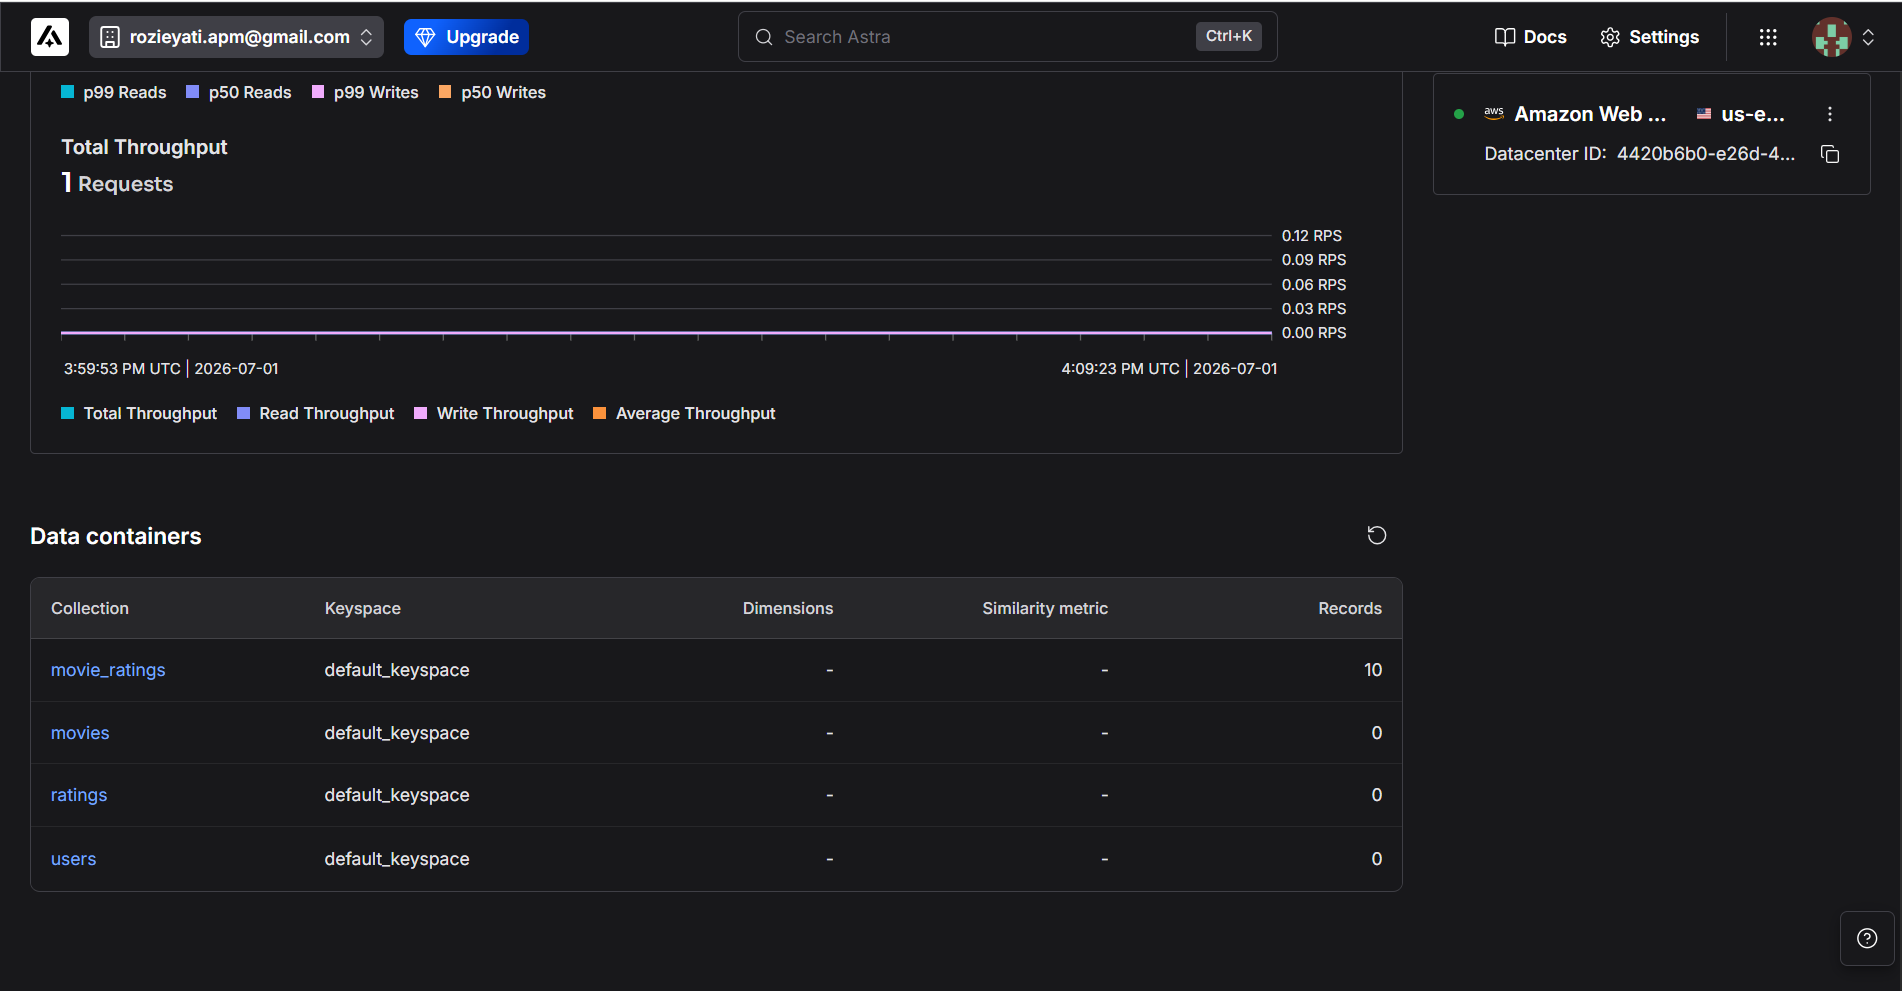**

Figure 7.1.1 illustrates the DataStax Astra DB dashboard following the implementation of the proposed data pipeline. The dashboard confirms that the analytical collections (movie_ratings, movies, ratings, and users) were successfully created within the default keyspace. The presence of records in the movie_ratings collection verifies that Apache Spark successfully persisted the processed analytical data into Apache Cassandra. This confirms the successful implementation of the analytical storage layer within the proposed polyglot persistence architecture.

### **7.1.2 Stored Analytical Records in the movie_ratings Collection**

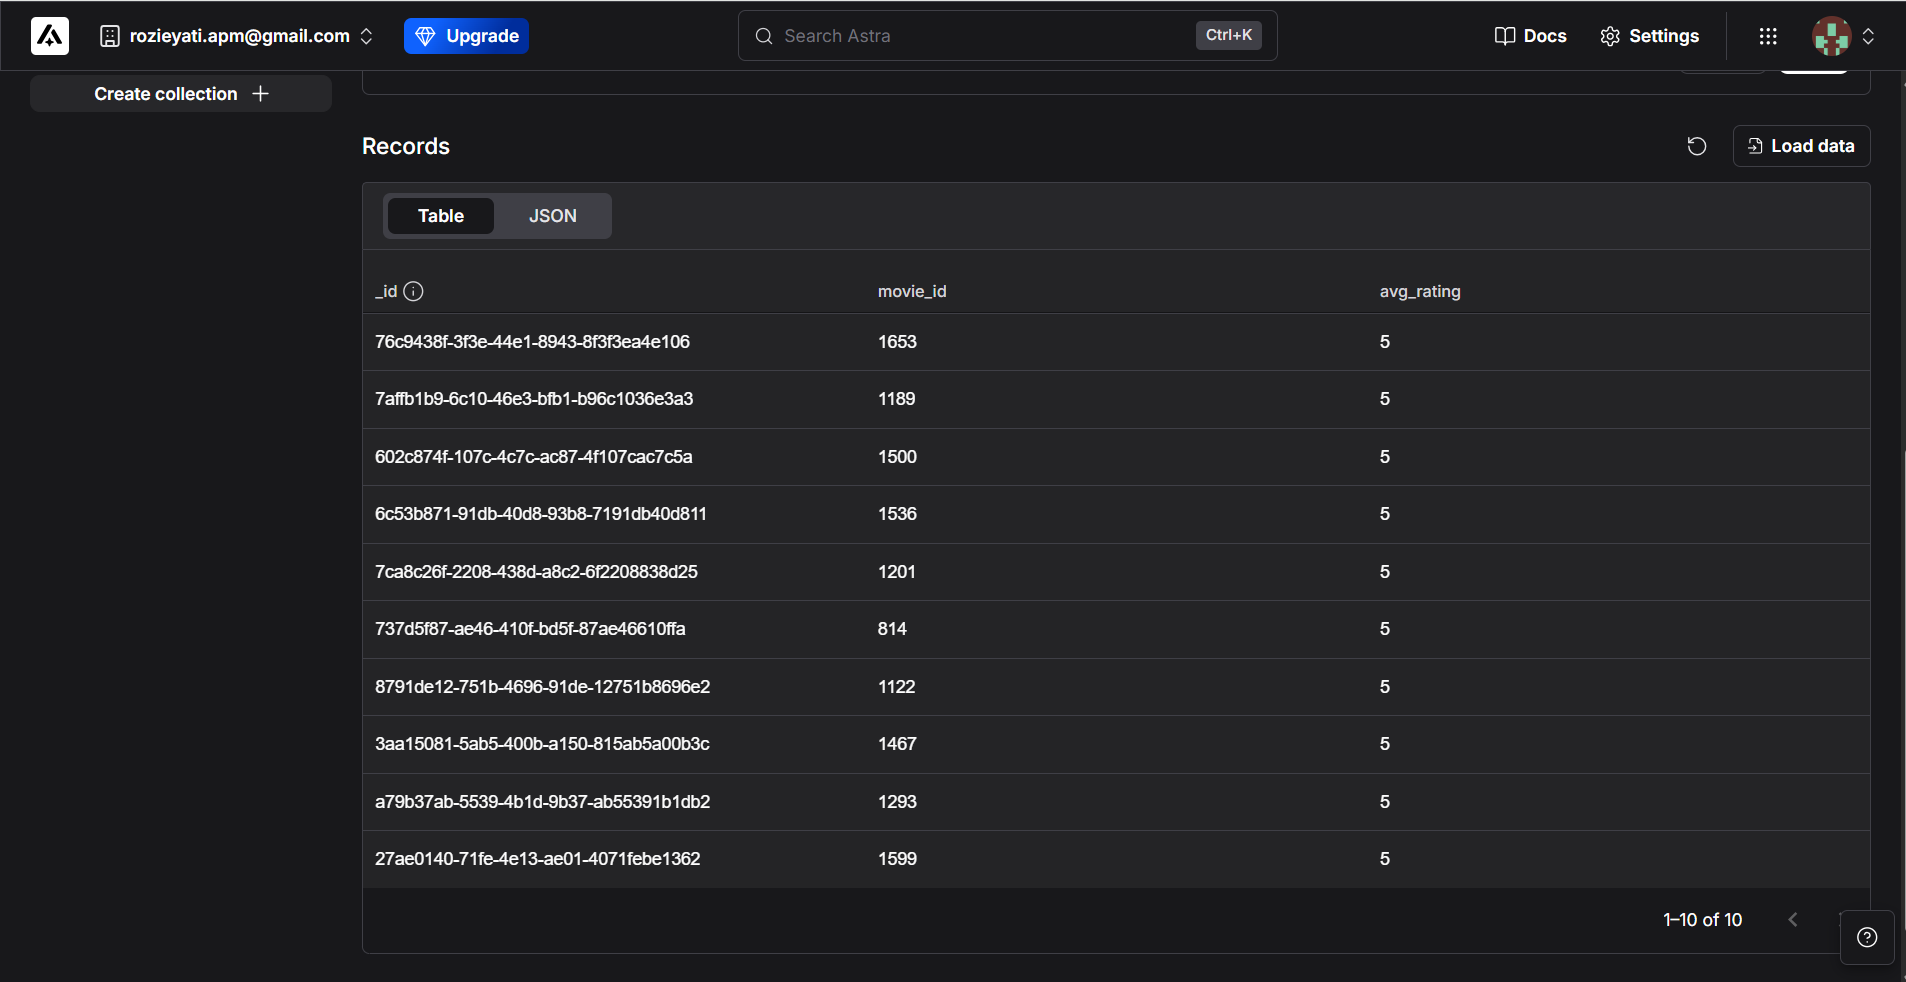

Figure 7.1.2 presents sample records stored within the movie_ratings collection. The successful persistence of these analytical records confirms that the transformed MovieLens data maintained its integrity throughout the Extract, Transform, and Load (ETL) process. The stored documents are immediately available for subsequent analytical queries and dashboard visualisation, demonstrating the effectiveness of Apache Cassandra as the analytical database within the proposed architecture.

## **7.2 Verification of MongoDB Implementation**

### **Figure 7.2.1 MongoDB Database and Collections**
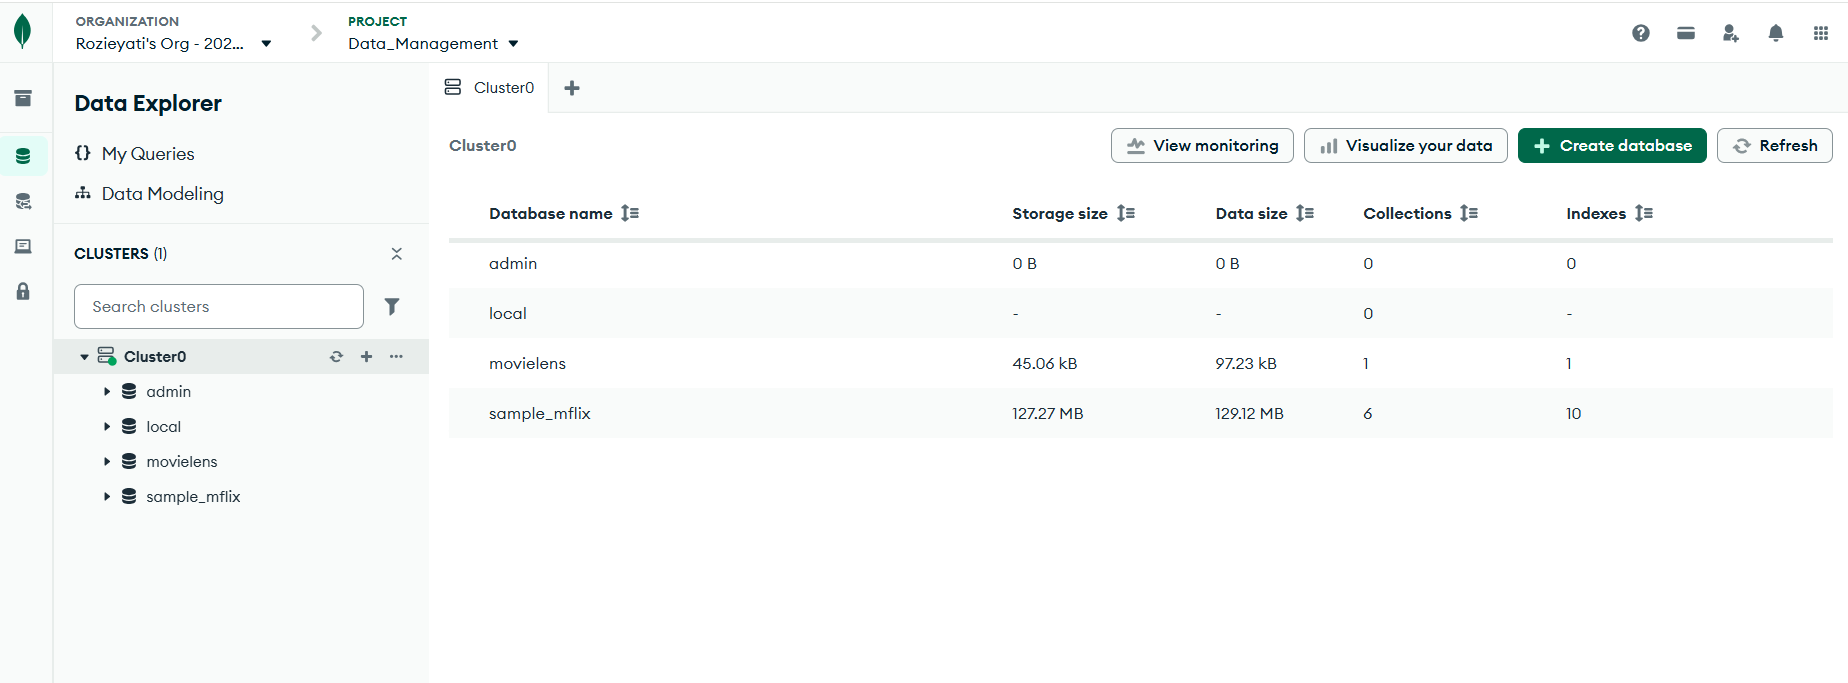


Figure 7.2.1 presents the MongoDB Atlas Data Explorer following the successful implementation of the proposed multi-model data pipeline. The existence of the movielens database and the users collection confirms that the processed MovieLens user profile data was successfully persisted into MongoDB after undergoing transformation in Apache Spark. This demonstrates the successful deployment of the operational data storage layer within the proposed polyglot persistence architecture.

Furthermore, the creation of the collection together with its associated index verifies that MongoDB is capable of efficiently organising and managing semi-structured demographic information using its document-oriented data model. Unlike relational databases that require predefined schemas, MongoDB supports flexible document structures, enabling the storage of heterogeneous user attributes while maintaining efficient query performance. This flexibility is particularly advantageous for recommendation systems where user profiles may evolve over time without requiring schema modifications, thereby improving scalability and maintainability (Chodorow, 2020).

The successful establishment of the movielens database therefore validates the integration between Apache Spark and MongoDB Atlas, confirming that the operational storage layer is fully functional and capable of supporting subsequent demographic analysis and real-time user profile retrieval.

## **8.0 Conclusion**

This study successfully developed and evaluated a Scalable Multi-Model Data Pipeline by integrating Apache Spark, Apache Cassandra (DataStax Astra DB), and MongoDB to analyse the MovieLens 100K dataset. The proposed architecture effectively demonstrated the application of a polyglot persistence strategy, whereby analytical data and operational user profile data were managed using specialised NoSQL databases according to their respective storage and retrieval requirements.

Apache Spark served as the distributed processing engine responsible for data ingestion, preprocessing, integration, and aggregation. Through schema enforcement, relational joins, and distributed transformations, raw MovieLens datasets were successfully converted into structured analytical datasets suitable for large-scale analysis. The implementation confirmed that Spark efficiently handled data preparation while maintaining scalability and supporting high-performance analytical processing.

Apache Cassandra (DataStax Astra DB) was successfully implemented as the analytical storage layer for aggregated movie performance metrics. The persistence and retrieval of analytical records verified Cassandra's capability to provide high-throughput, low-latency access for dashboard-oriented queries. Meanwhile, MongoDB functioned as the operational data store by successfully storing 943 user demographic records using its flexible document-oriented data model. The successful implementation of both databases validated the proposed polyglot persistence architecture and demonstrated seamless integration between distributed processing and cloud-based NoSQL storage platforms.

The exploratory data analysis further demonstrated the practical value of the proposed pipeline. The analytical results revealed meaningful patterns in movie popularity, rating distributions, user demographics, occupational characteristics, and regional engagement. Several analyses also highlighted the importance of considering review frequency when interpreting average ratings, thereby illustrating the need for statistically robust recommendation strategies. These findings confirm that integrating analytical metrics with demographic information provides richer insights than analysing either dataset independently.

Overall, all research objectives established at the beginning of this study were successfully achieved. The proposed architecture demonstrated efficient distributed processing, successful implementation of specialised NoSQL storage systems, and effective generation of meaningful analytical insights from large-scale heterogeneous datasets. The implementation further confirms that combining Apache Spark, Apache Cassandra, and MongoDB provides a scalable and flexible solution for modern data engineering applications that require both analytical processing and operational data management.

Although the proposed system successfully fulfils its objectives, several opportunities remain for future enhancement. Future work may incorporate larger datasets such as MovieLens 1M or MovieLens 20M to evaluate scalability under significantly higher data volumes. The implementation may also be extended by integrating streaming technologies such as Apache Kafka to support real-time data ingestion and continuous analytics. Furthermore, incorporating machine learning recommendation algorithms and interactive business intelligence dashboards using platforms such as Power BI, Tableau, or Apache Superset would further enhance the practical applicability of the proposed architecture for real-world recommendation systems.

In conclusion, this study demonstrates that a cloud-native, multi-model data pipeline combining Apache Spark, Apache Cassandra, and MongoDB provides an effective, scalable, and resilient architecture for managing both analytical and operational workloads. The successful implementation and evaluation confirm the suitability of the proposed framework for supporting modern large-scale data engineering and recommendation system applications.

## **References**

Brewer, E. A. (2012). CAP twelve years later: How the "rules" have changed. Computer, 45(2), 23–29. https://doi.org/10.1109/MC.2012.37

Chodorow, K. (2020). MongoDB: The definitive guide: Powerful and scalable data storage (3rd ed.). O'Reilly Media.

Han, J., Kamber, M., & Pei, J. (2012). Data mining: Concepts and techniques (3rd ed.). Morgan Kaufmann.

Harper, F. M., & Konstan, J. A. (2016). The MovieLens datasets: History and context. ACM Transactions on Interactive Intelligent Systems, 5(4), Article 19. https://doi.org/10.1145/2827872

Kleppmann, M. (2017). Designing data-intensive applications: The big ideas behind reliable, scalable, and maintainable systems. O'Reilly Media.

Kotu, V., & Deshpande, B. (2019). Data science: Concepts and practice (2nd ed.). Morgan Kaufmann.

Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). Mining of massive datasets (3rd ed.). Cambridge University Press.

Zaharia, M., Chen, A., Davidson, A., Ghodsi, A., Hong, S. A., Konwinski, A., Murching, S., Nykodym, T., Ogilvie, P., Parkhe, M., Xie, F., & Zumar, C. (2016). Apache Spark: A unified engine for big data processing. Communications of the ACM, 59(11), 56–65. https://doi.org/10.1145/2934664